In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

23850
44
8
writer_id
W27    550
W17    550
W01    550
W24    550
W11    550
Name: count, dtype: int64
writer_id
W51    550
W32    550
W25    550
W50    450
W39    300
Name: count, dtype: int64


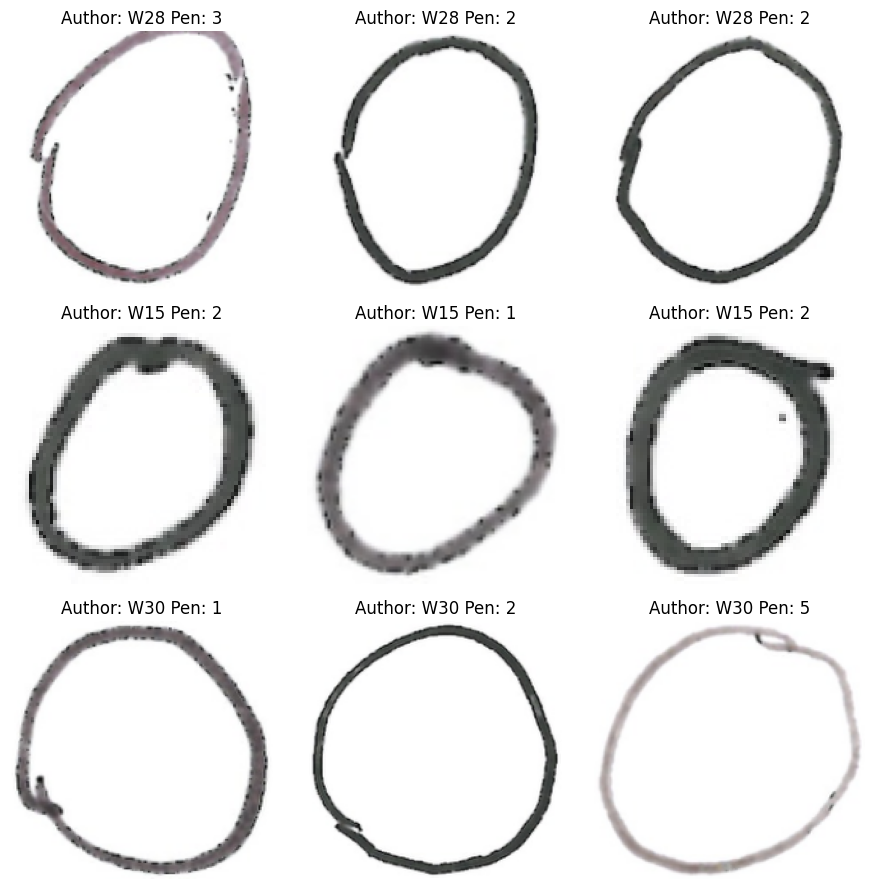

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

df = pd.read_csv('/kaggle/input/competitions/icdar-2026-circleid-writer-identification/train.csv')

print(len(df))
print(df['writer_id'].nunique())
print(df['pen_id'].nunique())

writer_counts = df['writer_id'].value_counts()
print(writer_counts.head())
print(writer_counts.tail())

sample_writers = random.sample(list(df['writer_id'].unique()), 3)

DATA_DIR = '/kaggle/input/competitions/icdar-2026-circleid-writer-identification'

plt.figure(figsize=(9, 9))
plot_idx = 1

for writer in sample_writers:
    writer_imgs = df[df['writer_id'] == writer]['image_path'].sample(3).values
    
    for img_path in writer_imgs:
        plt.subplot(3, 3, plot_idx)
        full_path = os.path.join(DATA_DIR, img_path)
        img = mpimg.imread(full_path)
        plt.imshow(img, cmap='gray')
        pen = df[df['image_path'] == img_path]['pen_id'].values[0]
        plt.title(f"Author: {writer} Pen: {pen}")
        plt.axis('off')
        plot_idx += 1

plt.tight_layout()
plt.show()

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df['label'] = le.fit_transform(df['writer_id'])

class CircleDataset(Dataset):
    def __init__(self, dataframe, data_dir, transform=None):
        self.dataframe = dataframe
        self.data_dir = data_dir
        self.transform = transform
        self.label_to_paths = dataframe.groupby('label')['image_path'].apply(list).to_dict()
        self.labels = list(self.label_to_paths.keys())
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        anchor_path = self.dataframe.iloc[idx]['image_path']
        anchor_label = self.dataframe.iloc[idx]['label']
        positive_path = random.choice(self.label_to_paths[anchor_label])
        while positive_path == anchor_path:
            positive_path = random.choice(self.label_to_paths[anchor_label])
        
        negative_label = random.choice([l for l in self.labels if l != anchor_label])
        negative_path = random.choice(self.label_to_paths[negative_label])

        def load_image(img_name):
            img_path = os.path.join(self.data_dir, img_name)
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img

        anchor_img = load_image(anchor_path)
        positive_img = load_image(positive_path)
        negative_img = load_image(negative_path)
        return anchor_img, positive_img, negative_img

class SimpleCircleDataset(Dataset):
    def __init__(self, dataframe, data_dir, transform=None, is_test=False):
        self.dataframe = dataframe
        self.data_dir = data_dir
        self.transform = transform
        self.is_test = is_test
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        img_path_rel = self.dataframe.iloc[idx]['image_path']
        img_path = os.path.join(self.data_dir, img_path_rel)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        if self.is_test:
            image_id = self.dataframe.iloc[idx]['image_id']
            return image, image_id
        else:
            label = self.dataframe.iloc[idx]['label']
            return image, label

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_df, val_df = train_test_split(df, test_size=0.1, random_state=42, stratify=df['label'])

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)


train_dataset = SimpleCircleDataset(dataframe=train_df, data_dir=DATA_DIR, transform=train_transform, is_test=False)
val_dataset = SimpleCircleDataset(dataframe=val_df, data_dir=DATA_DIR, transform=val_transform, is_test=False)

train_loader = DataLoader(train_dataset, 
                    batch_size=32, 
                    shuffle=True,
                    num_workers=4,
                    pin_memory=True
                )
val_loader = DataLoader(val_dataset, 
                    batch_size=32, 
                    shuffle=False,
                    num_workers=4,
                    pin_memory=True
                )

In [4]:
import random
from torch.utils.data import Sampler

class PKSampler(Sampler):
    def __init__(self, df, p_classes=16, k_samples=4):
        self.df = df
        self.p = p_classes
        self.k = k_samples
        self.labels = df['label'].unique()
        self.label_to_indices = df.groupby('label').groups
        self.label_to_indices = {k: list(v) for k, v in self.label_to_indices.items()}

    def __iter__(self):
        num_batches = len(self.df) // (self.p * self.k)
        for _ in range(num_batches):
            batch_indices = []
            classes = random.sample(list(self.labels), self.p)
            for c in classes:
                c_indices = self.label_to_indices[c]
                if len(c_indices) >= self.k:
                    batch_indices.extend(random.sample(c_indices, self.k))
                else:
                    batch_indices.extend(random.choices(c_indices, k=self.k))
            yield batch_indices

    def __len__(self):
        return len(self.df) // (self.p * self.k)

train_sampler = PKSampler(train_df, p_classes=16, k_samples=4)
val_sampler = PKSampler(val_df, p_classes=16, k_samples=4)

train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=4, pin_memory=True)

In [5]:
def batch_hard_triplet_loss(embeddings, labels, margin=1.0):
    dist_mat = torch.cdist(embeddings, embeddings, p=2)

    labels = labels.unsqueeze(1)
    mask_pos = (labels == labels.T).float()
    mask_neg = (labels != labels.T).float()

    hardest_positive_dist = (dist_mat * mask_pos).max(dim=1)[0]

    max_dist = dist_mat.max().item()
    hardest_negative_dist = (dist_mat + max_dist * mask_pos).min(dim=1)[0]

    loss = torch.clamp(hardest_positive_dist - hardest_negative_dist + margin, min=0.0)
    
    return loss.mean()

In [6]:
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F

class CircleEmbeddingNet(nn.Module):
    def __init__(self, embedding_size=128):
        super().__init__()
        self.backbone = models.resnet18(weights='DEFAULT')
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_features, embedding_size)
    def forward(self, x):
        features = self.backbone(x)
        return F.normalize(features, p=2, dim=1)

model = CircleEmbeddingNet(embedding_size=128)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]


In [7]:
import torch.optim as optim
from tqdm import tqdm
import copy
from scipy.spatial.distance import cdist

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(device)

cuda


In [8]:
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 500
best_loss = float('inf')
best_model_weights = None

patience = 15
epochs_not_improve = 0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', mininterval=500.0)

    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        embeddings = model(images)
        loss = batch_hard_triplet_loss(embeddings, labels, margin=1.5)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for images_val, labels_val in val_loader:
            images_val = images_val.to(device)
            labels_val = labels_val.to(device)

            emb_val = model(images_val)
            loss_val = batch_hard_triplet_loss(emb_val, labels_val, margin=1.5)
            val_running_loss += loss_val.item()
    val_loss = val_running_loss / len(val_loader)

    print(f'Epoch {epoch+1} done, Train Loss {avg_loss}, Val loss {val_loss}')

    if val_loss < best_loss:
        best_loss = val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_not_improve = 0
    else:
        epochs_not_improve += 1
        if epochs_not_improve >= patience:
            break
    

model.load_state_dict(best_model_weights)
model.eval()

Epoch 1/500: 100%|██████████| 335/335 [01:02<00:00,  5.40it/s]


Epoch 1 done, Train Loss 1.5257791679296921, Val loss 1.5047746155713055


Epoch 2/500: 100%|██████████| 335/335 [01:03<00:00,  5.32it/s]


Epoch 2 done, Train Loss 1.5025861491018266, Val loss 1.5018469932917002


Epoch 3/500: 100%|██████████| 335/335 [01:05<00:00,  5.11it/s]


...

Epoch 64/500: 100%|██████████| 335/335 [01:04<00:00,  5.17it/s]


Epoch 64 done, Train Loss 1.4999897230916948, Val loss 1.5031994259035266


Epoch 65/500: 100%|██████████| 335/335 [01:04<00:00,  5.17it/s]


Epoch 65 done, Train Loss 1.500290759285884, Val loss 1.500184668077005


CircleEmbeddingNet(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

In [9]:
def extract_embeddings(loader):
    embs, lbls = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            embs.append(model(images).cpu().numpy())
            if isinstance(labels, torch.Tensor):
                lbls.append(labels.numpy())
            else:
                lbls.extend(labels)
    if isinstance(lbls[0], str):
        lbls = np.array(lbls)
    else:
        lbls = np.concatenate(lbls)
    return np.vstack(embs), lbls

extract_dataset = SimpleCircleDataset(dataframe=df, data_dir=DATA_DIR, transform=val_transform, is_test=False)
extract_loader = torch.utils.data.DataLoader(extract_dataset, batch_size=64, shuffle=False)

test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
test_dataset = SimpleCircleDataset(dataframe=test_df, data_dir=DATA_DIR, transform=val_transform, is_test=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

X_train, y_train = extract_embeddings(extract_loader)
X_test, test_ids = extract_embeddings(test_loader)

clusters = {}
for i in range(len(y_train)):
    label = y_train[i]
    if label not in clusters:
        clusters[label] = []
    clusters[label].append(X_train[i])

for label in clusters:
    clusters[label] = np.array(clusters[label])

In [10]:
#tsne = TSNE(n_components=2, random_state=42, perplexity=30)
#embeddings_2d = tsne.fit_transform(all_embeddings)

#plt.figure(figsize=(14, 10))
#scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=all_labels, cmap='tab20', alpha=0.7, s=20)
#plt.colorbar(scatter, label='Author ID')
#plt.xlabel('Dim 1')
#plt.ylabel('Dim 2')
#plt.show()

import numpy as np
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist

cluster_thresholds = {}
k_neighbors = 3

for label, cluster_points in clusters.items():
    intra_dists = cdist(cluster_points, cluster_points, metric='euclidean')
    avg_intra_dists = np.sort(intra_dists, axis=1)[:, 1:k_neighbors+1].mean(axis=1)
    cluster_thresholds[label] = np.percentile(avg_intra_dists, 95)

def predict_test_point(query_emb, multiplier=1.5):
    best_label = -1
    min_score = float('inf')
    
    for label, points in clusters.items():
        dists = np.linalg.norm(points - query_emb, axis=1)
        k_nearest = np.partition(dists, min(k_neighbors, len(dists))-1)[:k_neighbors]
        score = np.mean(k_nearest)
        if score < min_score:
            min_score = score
            best_label = label
            
    if best_label != -1:
        dynamic_limit = cluster_thresholds[best_label] * multiplier
        if min_score > dynamic_limit:
            return -1

    return best_label

add_df = pd.read_csv(os.path.join(DATA_DIR, 'additional_train.csv'))

known_classes = set(le.classes_)
add_df['label'] = add_df['writer_id'].apply(lambda x: le.transform([x])[0] if x in known_classes else -1)

add_dataset = SimpleCircleDataset(dataframe=add_df, data_dir=DATA_DIR, transform=val_transform, is_test=False)
add_loader = torch.utils.data.DataLoader(add_dataset, batch_size=64, shuffle=False, num_workers=2)

X_add, y_add_true = extract_embeddings(add_loader)

best_multiplier = 1.0
best_acc = 0.0
multipliers_to_test = np.arange(1.0, 3.1, 0.1)

for mult in multipliers_to_test:
    y_add_pred = []
    
    for query_emb in X_add:
        pred = predict_test_point(query_emb, multiplier=mult)
        y_add_pred.append(pred)
        
    acc = accuracy_score(y_add_true, y_add_pred)
    print(f"Mult {mult}, Acc: {acc}")
    
    if acc > best_acc:
        best_acc = acc
        best_multiplier = mult

Mult 1.0, Acc: 0.30609756097560975
Mult 1.1, Acc: 0.2704878048780488
Mult 1.2000000000000002, Acc: 0.2552439024390244
Mult 1.3000000000000003, Acc: 0.25121951219512195
Mult 1.4000000000000004, Acc: 0.2504268292682927
Mult 1.5000000000000004, Acc: 0.2501219512195122
Mult 1.6000000000000005, Acc: 0.2499390243902439
Mult 1.7000000000000006, Acc: 0.25
Mult 1.8000000000000007, Acc: 0.2497560975609756
Mult 1.9000000000000008, Acc: 0.2496951219512195
Mult 2.000000000000001, Acc: 0.2497560975609756
Mult 2.100000000000001, Acc: 0.2498170731707317
Mult 2.200000000000001, Acc: 0.2498780487804878
Mult 2.300000000000001, Acc: 0.2498780487804878
Mult 2.4000000000000012, Acc: 0.2498780487804878
Mult 2.5000000000000013, Acc: 0.2498780487804878
Mult 2.6000000000000014, Acc: 0.2500609756097561
Mult 2.7000000000000015, Acc: 0.2500609756097561
Mult 2.8000000000000016, Acc: 0.2500609756097561
Mult 2.9000000000000017, Acc: 0.2501219512195122
Mult 3.0000000000000018, Acc: 0.2501219512195122


In [11]:
final_predictions = [predict_test_point(emb, multiplier=best_multiplier) for emb in X_test]

final_labels = []

for pred in final_predictions:
    if pred == -1:
        final_labels.append('-1')
    else:
        orig_id = le.inverse_transform([pred])[0]
        final_labels.append(orig_id)

submission_df = pd.DataFrame({
    'image_id': test_ids,
    'writer_id': final_labels
})

submission_df.to_csv('submission.csv', index=False)

In [12]:
print(submission_df.shape)

(5905, 2)
